![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

**Znaleźć rozkład prawdopodobieństwa, dystrybuantę, wartość oczekiwaną i wariancję zmiennej losowej $X$ – sumy oczek otrzymanej w wyniku rzutu dwiema czworościennymi kostkami do gry.**

In [1]:
from scipy import stats as st
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

Wygenerownie wszystkich możliwych wartości przyjmowanych przez tę zmienną losową i odpowiadających im częstości

In [2]:
W=dict()
for i in range(1,7):
    for j in range(1,7):
        if i+j in W:
            W[i+j]+=1 # jeśli klucz już istnieje po prostu dolicz do odpowiadajacej mu wartości 1
        else:
            W[i+j]=1 # jeśli klucz nie istnieje, utwórz klucz i ustaw liczbę jego wystąpień równą 1
            
W  # wypisz zdarzenia i częstości

{2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 5, 9: 4, 10: 3, 11: 2, 12: 1}

In [3]:
P=sorted(list(W.items()), key=lambda x: x[0]) # posortowanie krotek po wartościach zmiennej losowej x

xk = list(map(lambda x:x[0],P)) # wartości przyjmowane przez zmienną losową
#określenie prawdopodobieństw
pk = list(map(lambda x:x[-1],P)) # obliczenie częstości
N = sum(pk) # obliczenie sumy ilości zdarzeń
pk = list(map(lambda x:x/N,pk)) # ostatecznie - policzone prawdopodobieństwa

rozklad = st.rv_discrete(name='Rozkład z ćw.', values=(xk, pk)) #utworzenie rozkładu

In [4]:
E = rozklad.expect() # wartość oczekiwana
V = rozklad.var() # wariancja
[E,V]

[6.999999999999998, 5.833333333333357]

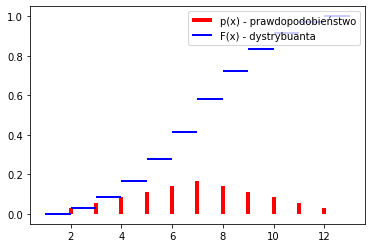

In [6]:
xk=rozklad.xk
p = rozklad.pmf(xk)
F = rozklad.cdf(xk)
plt.vlines(xk, 0, p, colors='r', lw=4)
plt.hlines(np.append([0],F), np.append([min(xk)-1],xk), np.append(xk,[max(xk)+1]), colors='b', lw=2)
plt.legend(["p(x) - prawdopodobieństwo","F(x) - dystrybuanta"])
pass